In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split 


In [3]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network) Good for binary calssification tasks

from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
#accuracy_score: Measures how many predictions are correct
#clclassification_report: shows precision , recall and f1-score for each class.
# coconfusion_matrix: Shows where the model is making correct vs wrong predictions

#------------------------------------------
#  Tensorflow / keras (Deep learning utilites) 
#-----------------------------------------
import tensorflow as tf 

from tensorflow.keras.models import Sequential 
# Lets you build a neural network layer-by-layer in a linear fashion

from tensorflow.keras.layers import Dense 
#fully connected layer (every neuron connects to every neuron in hte next layer)

from tensorflow.keras.layers import Dropout
#Randomly drops some neurons during training to prevent overfitting.abs

from tensorflow.keras.utils import to_categorical 
# Converts class labels (like 0,1,2) into one-hot encoded format (e.g., [1,0,0],[0,1,0])

In [4]:
from sklearn.datasets import load_iris
iris=load_iris()

In [5]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [9]:
X = df.drop('target',axis=1) 
y = df['target']

In [10]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

In [12]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [13]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
per = Perceptron(max_iter=1000,random_state=42)
per.fit(X_train_scaled,y_train)

Perceptron(random_state=42)

In [15]:
y_pred_percep = per.predict(X_test_scaled)

In [16]:
print("accuracy Score:",accuracy_score(y_test,y_pred_percep))
print("accuracy Score:",classification_report(y_test,y_pred_percep))


accuracy Score: 0.8666666666666667
accuracy Score:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.70      0.78        10
           2       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



In [17]:
y_train_cat = to_categorical(y_train,num_classes=3)

In [18]:
y_train_cat.shape

(120, 3)

In [19]:
y_test_cat = to_categorical(y_test,num_classes=3)

In [20]:
y_test_cat.shape

(30, 3)

In [21]:
model = Sequential([
    Dense(16,input_dim=4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])
    

In [22]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
history = model.fit(X_train_scaled,y_train_cat,epochs=100,batch_size=8,validation_split=0.2,verbose=1) 

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3395 - loss: 1.2800 - val_accuracy: 0.5833 - val_loss: 1.1440
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3753 - loss: 1.2164 - val_accuracy: 0.5417 - val_loss: 1.0919
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4635 - loss: 1.1086 - val_accuracy: 0.5417 - val_loss: 1.0449
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4926 - loss: 1.0549 - val_accuracy: 0.5000 - val_loss: 0.9991
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4760 - loss: 1.0241 - val_accuracy: 0.5833 - val_loss: 0.9557
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7125 - loss: 0.9509 - val_accuracy: 0.6250 - val_loss: 0.9210
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6353 - loss: 0.9571 - val_accuracy: 0.6250 - val_loss: 0.8891
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7572 - loss: 0.8907 - val_accuracy: 0.62

In [24]:
loss, acc = model.evaluate(X_test_scaled,y_test_cat,verbose=0)
print(acc)

0.9666666388511658


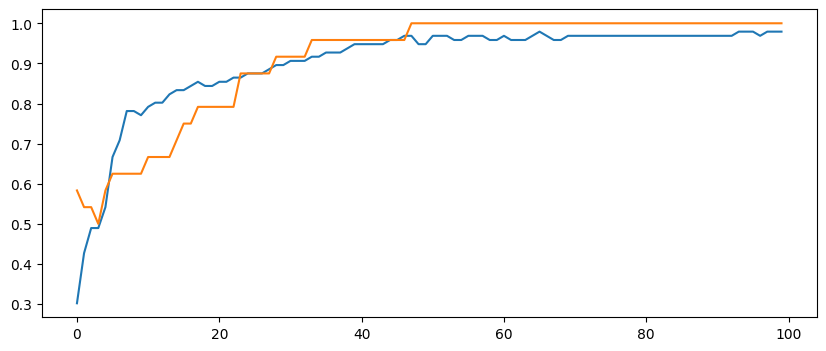

In [25]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label="train Acc")
plt.plot(history.history['val_accuracy'],label="val Acc")

In [27]:
v1 = [1,2,3,4]

In [28]:
v1

[1, 2, 3, 4]

In [37]:
model.predict(np.array([[-1,0.2,0.1,0.1]]))   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[0.1304086 , 0.8623168 , 0.00727462]], dtype=float32)

In [39]:
model.save("model.keras")

In [43]:
import joblib

In [44]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [45]:
X_test_scaled[0]

array([-1.72156775, -0.10821272, -1.40250384, -1.32327558])